<a href="https://colab.research.google.com/github/Sanskar-cpu-sudo/Deep-Learning/blob/main/Assignment4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 4
 — LSTM-Based Time-Series Forecasting

**Dataset:** Airline Passengers

This notebook develops and compares LSTM-based forecasting models using **6-month, 12-month, and 24-month look-back windows**.

The objective is to study how the amount of historical information supplied to the LSTM affects forecasting performance.


## Objective

Develop an LSTM-based model for time-series forecasting and compare three different look-back windows:

- **6 months** — short-term historical context
- **12 months** — one complete yearly seasonal cycle
- **24 months** — two complete yearly seasonal cycles

Each model is evaluated using **MAE** and **RMSE**. The final comparison is based on the actual experimental results.


In [ ]:
import os
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.21.0


## 1. Load the Dataset

The notebook checks whether the dataset already exists locally. If it does not, it downloads the CSV automatically and saves it to the repository's `data/` directory.


In [ ]:
DATA_DIR = "../data"
DATA_PATH = os.path.join(DATA_DIR, "airline-passengers.csv")
DATA_URL = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"

os.makedirs(DATA_DIR, exist_ok=True)

if not os.path.exists(DATA_PATH):
    print("Dataset not found locally. Downloading...")
    pd.read_csv(DATA_URL).to_csv(DATA_PATH, index=False)
    print("Dataset downloaded to:", DATA_PATH)
else:
    print("Using local dataset:", DATA_PATH)

df = pd.read_csv(DATA_PATH)
df["Month"] = pd.to_datetime(df["Month"])
df = df.sort_values("Month").reset_index(drop=True)

print("Dataset shape:", df.shape)
df.head()


Dataset not found locally. Downloading...
Dataset downloaded to: ../data\airline-passengers.csv
Dataset shape: (144, 2)


,Month,Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [ ]:
print("Missing values:")
print(df.isnull().sum())

print("\nDataset information:")
df.info()


Missing values:
Month         0
Passengers    0
dtype: int64

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Month       144 non-null    datetime64[us]
 1   Passengers  144 non-null    int64         
dtypes: datetime64[us](1), int64(1)
memory usage: 2.4 KB


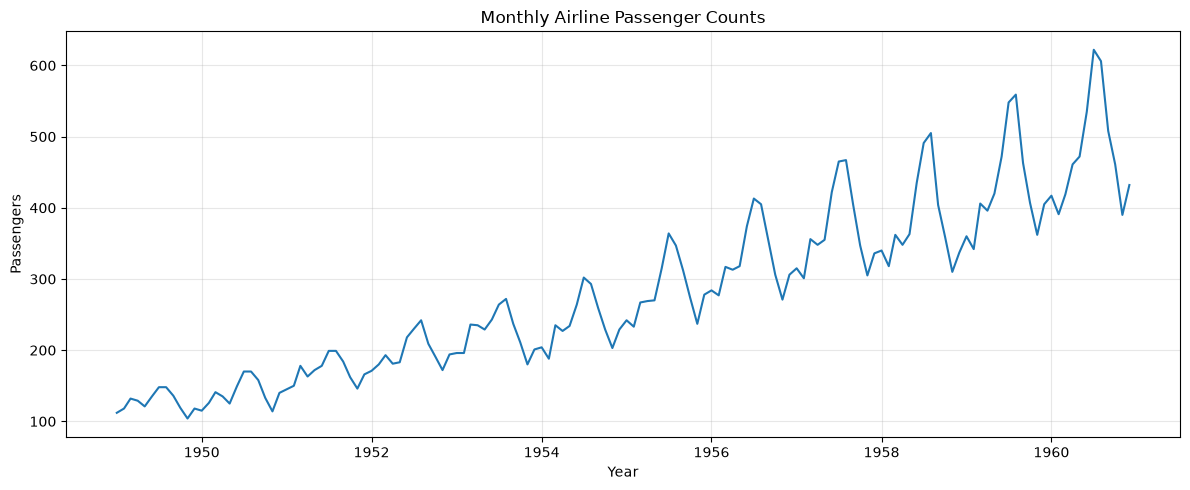

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(df["Month"], df["Passengers"])
plt.title("Monthly Airline Passenger Counts")
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("./results/passenger_time_series.png", dpi=300)
plt.show()


## 2. Train-Test Split

Because this is a time-series problem, the data is split **chronologically** rather than randomly.

- First 80% → training
- Final 20% → testing

This prevents future observations from being used to train the model.


In [ ]:
values = df[["Passengers"]].values.astype("float32")

train_size = int(len(values) * 0.80)

train_data = values[:train_size]
test_data = values[train_size:]

print("Total observations:", len(values))
print("Training observations:", len(train_data))
print("Testing observations:", len(test_data))


Total observations: 144
Training observations: 115
Testing observations: 29


## 3. Normalize the Data

Min-Max scaling converts passenger counts to the range [0, 1].

The scaler is fitted **only on the training data** to avoid data leakage.


In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))

train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

print("Training scaled range:",
      train_scaled.min(), "to", train_scaled.max())


Training scaled range: 0.0 to 1.0


## 4. Create Time-Series Sequences

For each look-back window, the LSTM receives a fixed number of previous months and predicts the following month.

For example, with a 12-month window:

```text
Months 1–12  → Month 13
Months 2–13  → Month 14
Months 3–14  → Month 15
...
```

The same procedure is repeated for 6 and 24 months.


In [ ]:
def create_sequences(data, look_back):
    X, y = [], []

    for i in range(look_back, len(data)):
        X.append(data[i - look_back:i, 0])
        y.append(data[i, 0])

    return np.array(X), np.array(y)


def prepare_train_test_sequences(train_scaled, test_scaled, look_back):
    X_train, y_train = create_sequences(train_scaled, look_back)

    # Include the final training observations so that the first
    # test prediction has the required historical context.
    test_input = np.concatenate([
        train_scaled[-look_back:],
        test_scaled
    ])

    X_test, y_test = create_sequences(test_input, look_back)

    X_train = X_train.reshape(
        X_train.shape[0], X_train.shape[1], 1
    )

    X_test = X_test.reshape(
        X_test.shape[0], X_test.shape[1], 1
    )

    return X_train, y_train, X_test, y_test


## 5. Define the LSTM Model

To make the comparison fair, the **same model architecture and training configuration** are used for all three look-back windows.

Only the input sequence length changes.


In [ ]:
def build_lstm_model(look_back):
    model = Sequential([
        Input(shape=(look_back, 1)),
        LSTM(64),
        Dropout(0.2),
        Dense(32, activation="relu"),
        Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )

    return model


## 6. Run the Three Experiments

Each experiment:

1. Creates sequences using the selected look-back window.
2. Builds a fresh LSTM model.
3. Trains the model.
4. Generates predictions on the test set.
5. Converts predictions back to the original passenger scale.
6. Calculates MAE and RMSE.
7. Records the training time and number of epochs.


In [ ]:
LOOK_BACK_WINDOWS = [6, 12, 24]

results = []
predictions = {}
histories = {}

for look_back in LOOK_BACK_WINDOWS:
    print("=" * 60)
    print(f"Training LSTM with {look_back}-month look-back")
    print("=" * 60)

    X_train, y_train, X_test, y_test = prepare_train_test_sequences(
        train_scaled,
        test_scaled,
        look_back
    )

    print("X_train:", X_train.shape)
    print("X_test :", X_test.shape)

    model = build_lstm_model(look_back)

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True
    )

    start_time = time.perf_counter()

    history = model.fit(
        X_train,
        y_train,
        epochs=100,
        batch_size=16,
        validation_split=0.10,
        shuffle=False,
        callbacks=[early_stopping],
        verbose=1
    )

    training_time = time.perf_counter() - start_time

    pred_scaled = model.predict(X_test, verbose=0)

    y_test_actual = scaler.inverse_transform(
        y_test.reshape(-1, 1)
    ).flatten()

    pred_actual = scaler.inverse_transform(
        pred_scaled
    ).flatten()

    mae = mean_absolute_error(y_test_actual, pred_actual)
    rmse = np.sqrt(
        mean_squared_error(y_test_actual, pred_actual)
    )

    results.append({
        "Look-back (months)": look_back,
        "MAE": mae,
        "RMSE": rmse,
        "Epochs": len(history.history["loss"]),
        "Training Time (seconds)": training_time
    })

    predictions[look_back] = {
        "actual": y_test_actual,
        "predicted": pred_actual
    }

    histories[look_back] = history

    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"Epochs: {len(history.history['loss'])}")
    print(f"Training time: {training_time:.2f} seconds")
    print()


Training LSTM with 6-month look-back
X_train: (109, 6, 1)
X_test : (29, 6, 1)
Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 0.0911 - mae: 0.2565 - val_loss: 0.1931 - val_mae: 0.4159
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0299 - mae: 0.1256 - val_loss: 0.0476 - val_mae: 0.1671
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0152 - mae: 0.1019 - val_loss: 0.0286 - val_mae: 0.1343
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0301 - mae: 0.1491 - val_loss: 0.0367 - val_mae: 0.1641
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0251 - mae: 0.1366 - val_loss: 0.0288 - val_mae: 0.1357
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0185 - mae: 0.1126 - val_loss: 0.0270 - val_mae: 0.1327
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0125 - mae: 0.0920 - val_loss: 0.0284 - val_mae: 0.1356
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0163 - mae: 0.1013 - val_loss: 0.0324 - val_mae: 0

## 7. Comparison of Results


In [ ]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Look-back (months)"
).reset_index(drop=True)

results_df.round(2)


,Look-back (months),MAE,RMSE,Epochs,Training Time (seconds)
0,6,70.15,84.48,21,4.10
1,12,60.23,79.90,20,3.72
2,24,63.14,85.05,20,3.64


### Best Model

For MAE and RMSE, **lower values indicate better forecasting performance**.

The best look-back window is selected using the lowest RMSE.


In [ ]:
best_row = results_df.loc[results_df["RMSE"].idxmin()]

print("Best Look-back Window:", int(best_row["Look-back (months)"]), "months")
print(f"Best MAE: {best_row['MAE']:.2f}")
print(f"Best RMSE: {best_row['RMSE']:.2f}")


Best Look-back Window: 12 months
Best MAE: 60.23
Best RMSE: 79.90


## 8. Metric Comparison



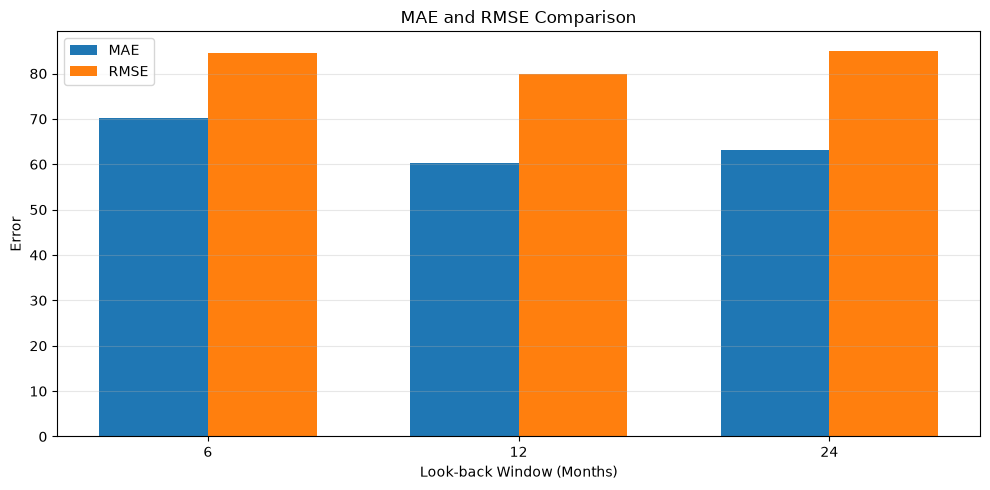

In [ ]:
x = np.arange(len(results_df))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(
    x - width / 2,
    results_df["MAE"],
    width,
    label="MAE"
)
plt.bar(
    x + width / 2,
    results_df["RMSE"],
    width,
    label="RMSE"
)

plt.xticks(
    x,
    results_df["Look-back (months)"].astype(str)
)
plt.xlabel("Look-back Window (Months)")
plt.ylabel("Error")
plt.title("MAE and RMSE Comparison")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("./results/window_metric_comparison.png", dpi=300)
plt.show()


## 9. Actual vs Predicted — All Look-back Windows

This visualization compares the predictions generated by the 6-, 12-, and 24-month models on the same test period.


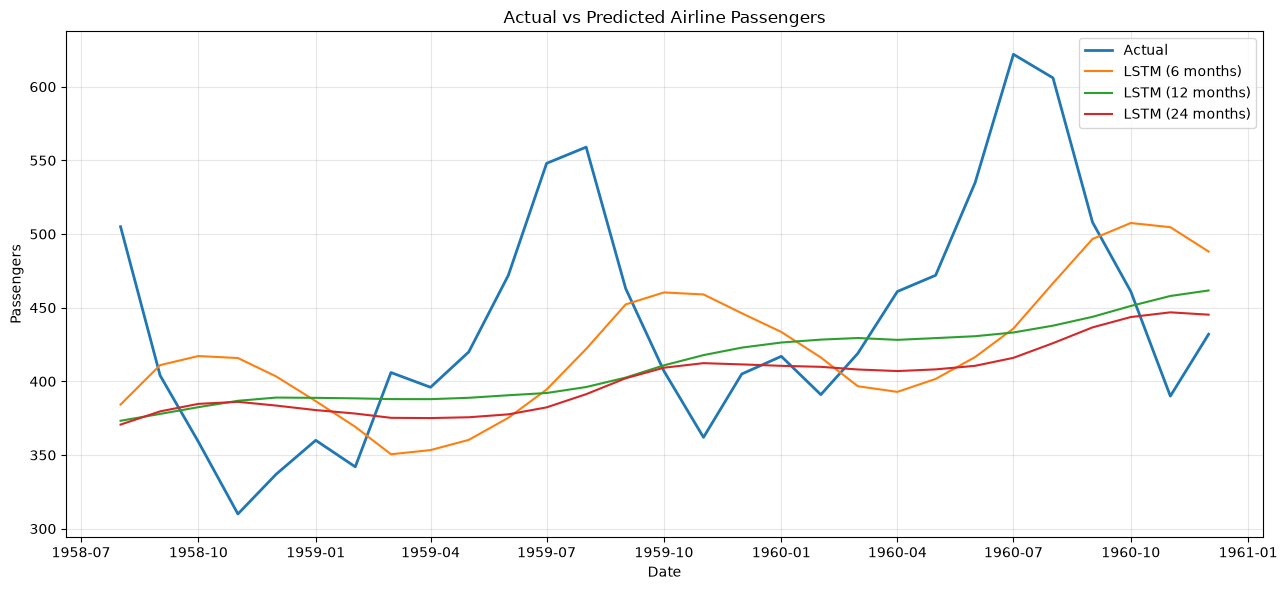

In [ ]:
test_dates = df["Month"].iloc[train_size:].reset_index(drop=True)

plt.figure(figsize=(13, 6))

plt.plot(
    test_dates,
    predictions[6]["actual"],
    label="Actual",
    linewidth=2
)

for look_back in LOOK_BACK_WINDOWS:
    plt.plot(
        test_dates,
        predictions[look_back]["predicted"],
        label=f"LSTM ({look_back} months)"
    )

plt.title("Actual vs Predicted Airline Passengers")
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("./results/all_windows_actual_vs_predicted.png", dpi=300)
plt.show()


## 10. Individual Prediction Plots



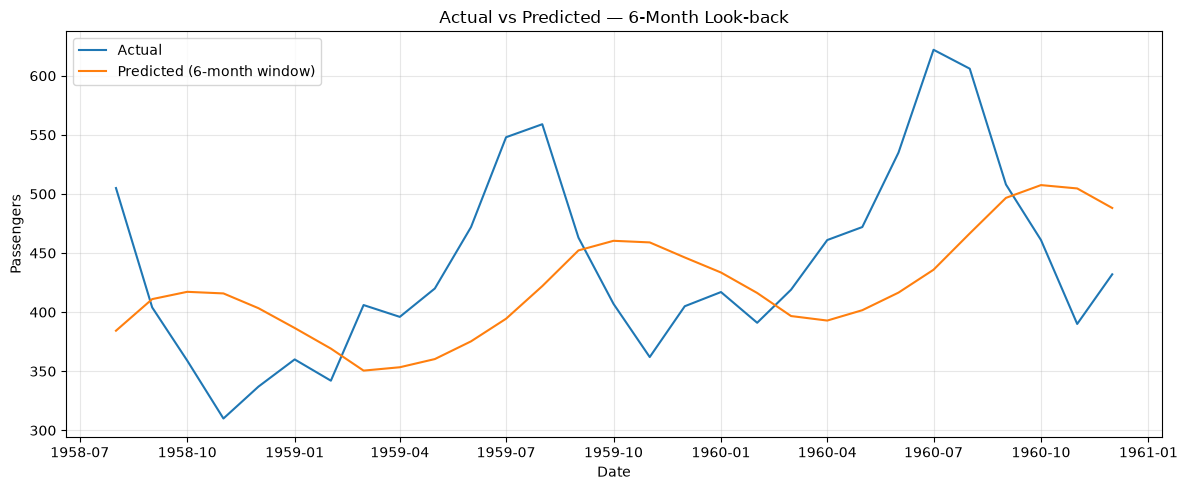

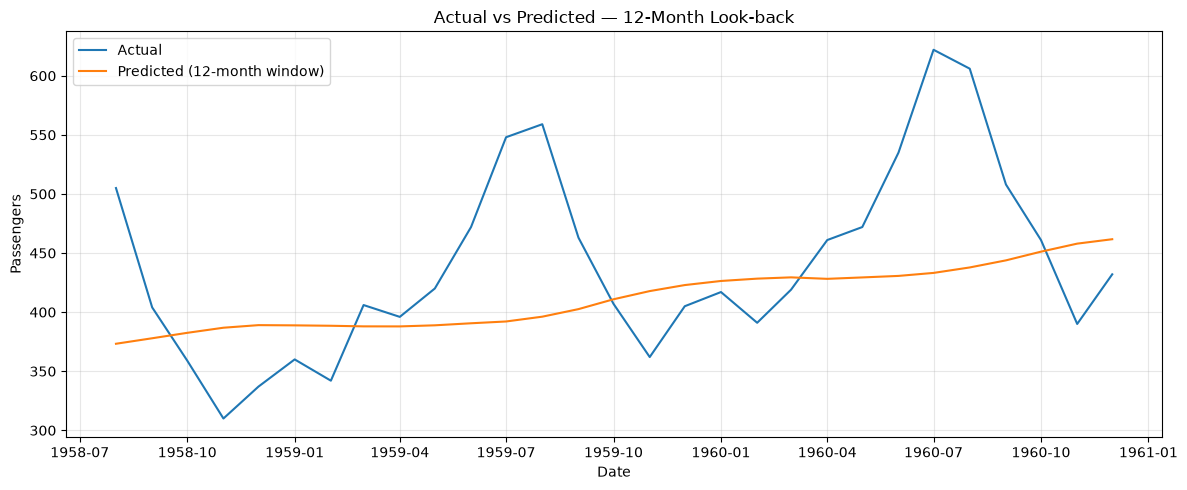

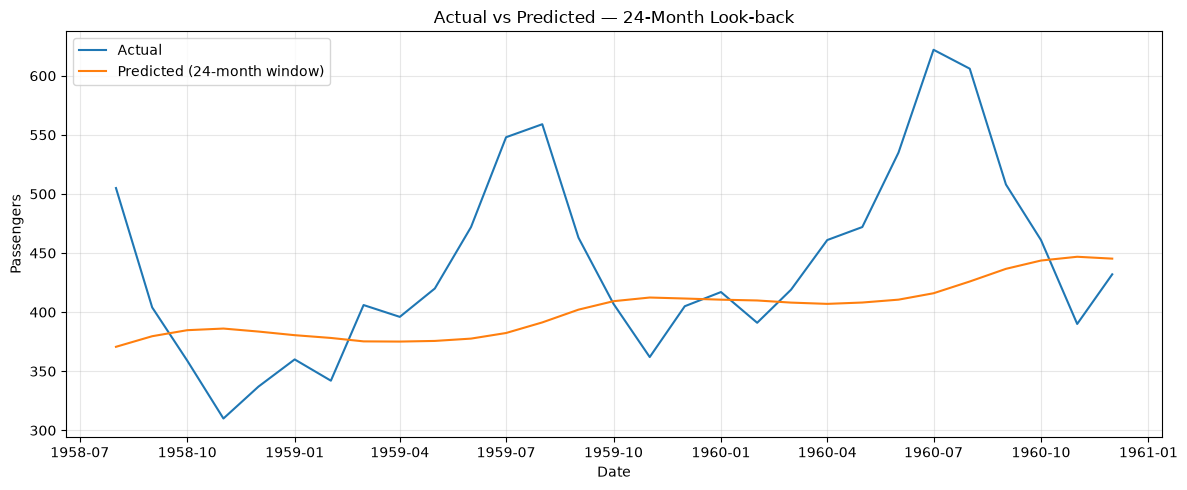

In [ ]:
for look_back in LOOK_BACK_WINDOWS:
    plt.figure(figsize=(12, 5))

    plt.plot(
        test_dates,
        predictions[look_back]["actual"],
        label="Actual"
    )

    plt.plot(
        test_dates,
        predictions[look_back]["predicted"],
        label=f"Predicted ({look_back}-month window)"
    )

    plt.title(
        f"Actual vs Predicted — {look_back}-Month Look-back"
    )
    plt.xlabel("Date")
    plt.ylabel("Passengers")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.savefig(
        f"./results/prediction_{look_back}_month_window.png",
        dpi=300
    )

    plt.show()


## 11. Training and Validation Loss Comparison



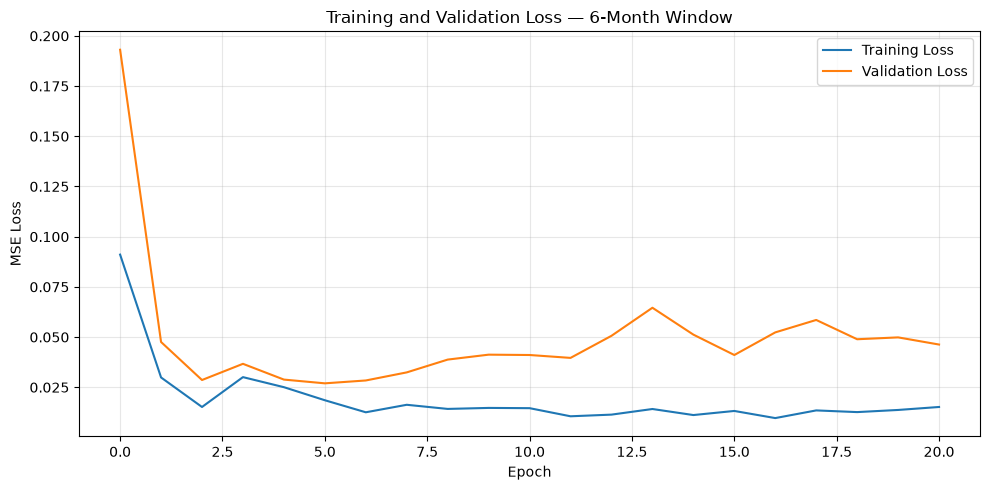

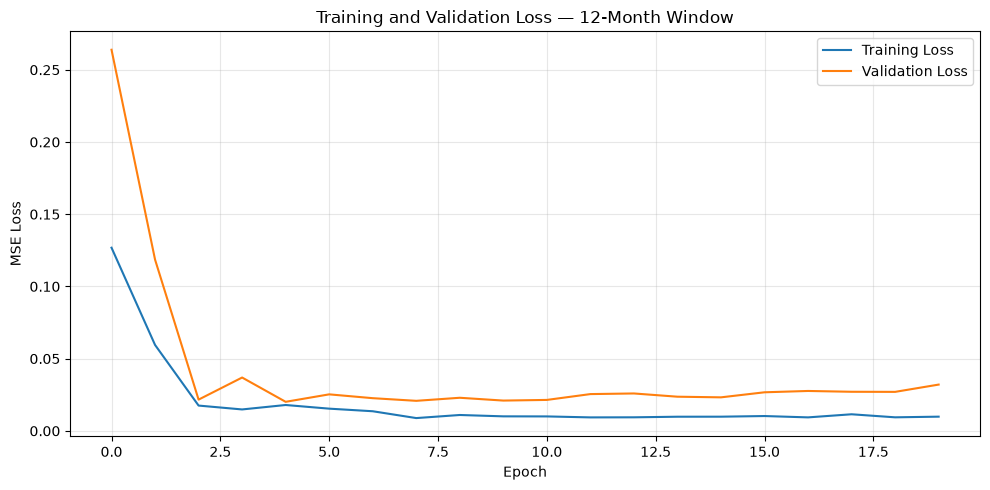

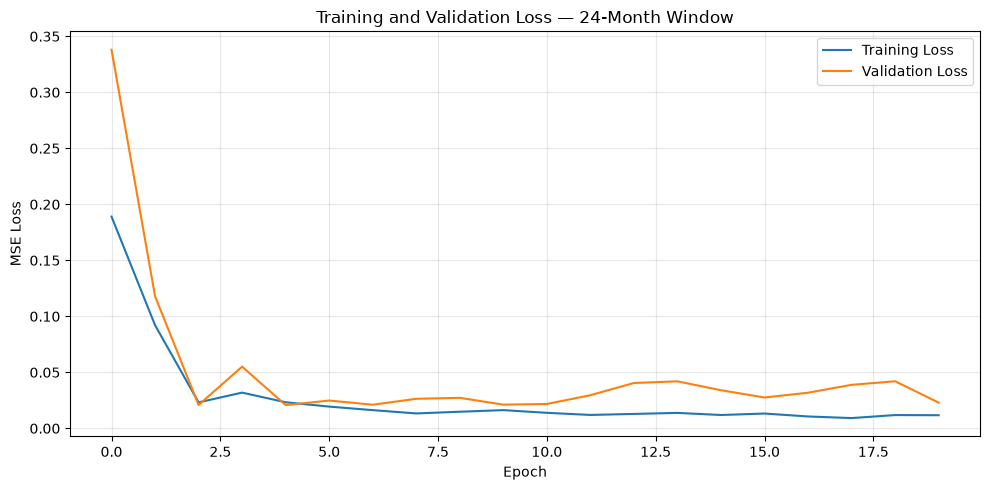

In [ ]:
for look_back in LOOK_BACK_WINDOWS:
    history = histories[look_back]

    plt.figure(figsize=(10, 5))
    plt.plot(
        history.history["loss"],
        label="Training Loss"
    )
    plt.plot(
        history.history["val_loss"],
        label="Validation Loss"
    )

    plt.title(
        f"Training and Validation Loss — {look_back}-Month Window"
    )
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.savefig(
        f"./results/loss_{look_back}_month_window.png",
        dpi=300
    )

    plt.show()


## 12. Interpretation

### 6-Month Window
Uses relatively recent history. It may capture short-term changes but does not contain a complete yearly seasonal cycle.

### 12-Month Window
Contains one complete year of monthly observations. This makes it a natural choice for a dataset with yearly seasonality.

### 24-Month Window
Provides two complete yearly cycles and therefore gives the model more historical context. However, the longer sequence also increases the amount of information the model must process.

The final choice should be based on the **observed MAE and RMSE**, rather than assuming that a particular window will always perform best.


## 13. Conclusion

Three LSTM forecasting models were trained using 6-, 12-, and 24-month look-back windows. Their performance was compared using MAE and RMSE.

The experiment demonstrates how the amount of historical context affects time-series forecasting performance. Since the Airline Passengers dataset contains strong yearly seasonality, the 12-month window is particularly meaningful, while the 6- and 24-month windows provide useful shorter- and longer-context comparisons.

The best configuration should be selected based on the experimental evaluation results.
